2026-02-21 06:09:05.530066: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771654145.684013      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771654145.731215      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771654146.094466      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771654146.094520      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771654146.094523      23 computation_placer.cc:177] computation placer alr

Loading Training Set:
Found 27188 images belonging to 4 classes.
Loading Validation Set:
Found 6796 images belonging to 4 classes.
Loading Unseen Test Set:
Found 6400 images belonging to 4 classes.

⚖️ Calculating Class Weights to fix Imbalance...
MildDemented weight: 0.9482
ModerateDemented weight: 1.3142
NonDemented weight: 0.8850
VeryMildDemented weight: 0.9482


I0000 00:00:1771654180.874949      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1771654180.880900      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

🚀 Starting VGG19 Training for 50 Epochs...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50


I0000 00:00:1771654185.335428      87 service.cc:152] XLA service 0x7c505800e300 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771654185.335471      87 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1771654185.335476      87 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1771654185.954381      87 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/850 ━━━━━━━━━━━━━━━━━━━━ 3:29:46 15s/step - accuracy: 0.0625 - loss: 30.3554

I0000 00:00:1771654198.104930      87 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


850/850 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.5108 - loss: 2.4081
Epoch 1: val_accuracy improved from -inf to 0.71572, saving model to /kaggle/working/best_vgg19_model.keras
850/850 ━━━━━━━━━━━━━━━━━━━━ 260s 289ms/step - accuracy: 0.5109 - loss: 2.4066 - val_accuracy: 0.7157 - val_loss: 0.6265
Epoch 2/50
850/850 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.7028 - loss: 0.6012
Epoch 2: val_accuracy improved from 0.71572 to 0.80680, saving model to /kaggle/working/best_vgg19_model.keras
850/850 ━━━━━━━━━━━━━━━━━━━━ 237s 279ms/step - accuracy: 0.7028 - loss: 0.6012 - val_accuracy: 0.8068 - val_loss: 0.4589
Epoch 3/50
850/850 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.7693 - loss: 0.4759
Epoch 3: val_accuracy improved from 0.80680 to 0.84697, saving model to /kaggle/working/best_vgg19_model.keras
850/850 ━━━━━━━━━━━━━━━━━━━━ 237s 279ms/step - accuracy: 0.7693 - loss: 0.4759 - val_accuracy: 0.8470 - val_loss: 0.3769
Epoch 4/50
850/850 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step 

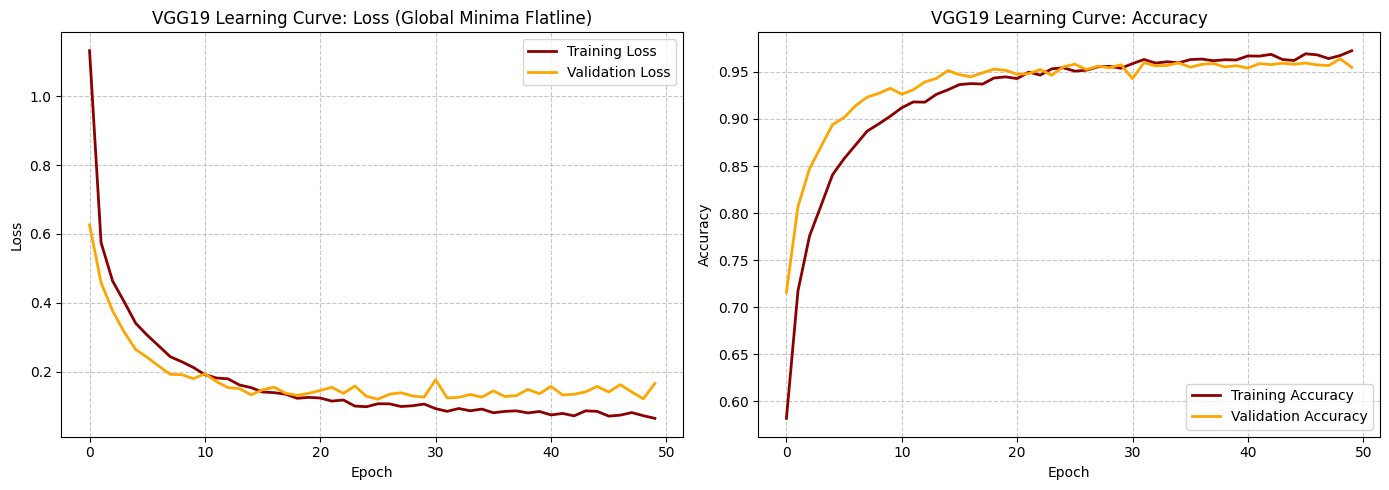


🧪 Evaluating on Unseen Test Set...
200/200 ━━━━━━━━━━━━━━━━━━━━ 44s 216ms/step
✅ Testing Time: 45.07 seconds

📊 Classification Report:
                  precision    recall  f1-score   support

    MildDemented       0.99      0.98      0.99       896
ModerateDemented       1.00      1.00      1.00        64
     NonDemented       0.98      0.99      0.99      3200
VeryMildDemented       0.99      0.98      0.98      2240

        accuracy                           0.99      6400
       macro avg       0.99      0.99      0.99      6400
    weighted avg       0.99      0.99      0.99      6400


🎯 Class-wise Accuracies:
MildDemented: 0.9810
ModerateDemented: 1.0000
NonDemented: 0.9919
VeryMildDemented: 0.9804


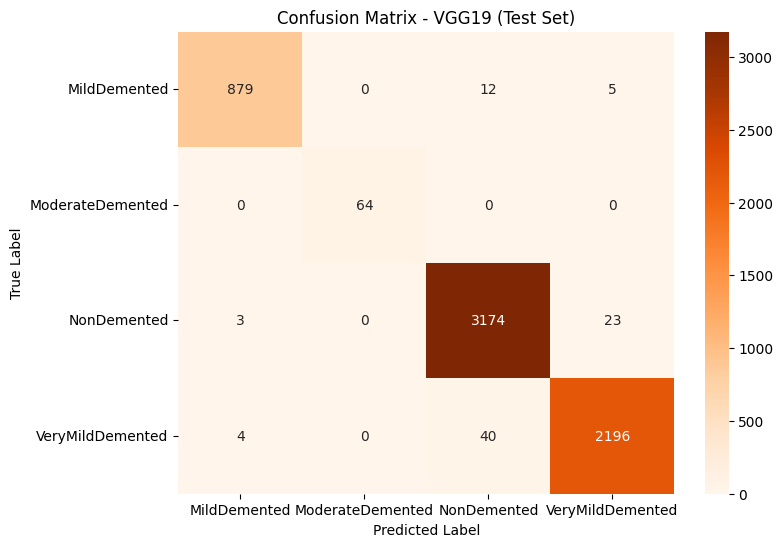

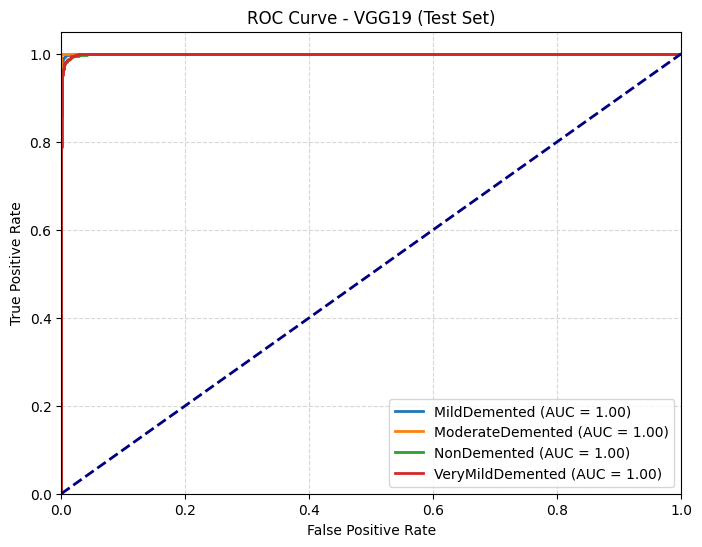


💾 Saved VGG19 correctness array for the final paired t-test.


In [1]:
import os
# Hide standard TensorFlow warnings for a cleaner output
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' 

import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.applications import VGG19
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ==========================================
# 1. Dataset Preparation (Research-Grade 3-Way Split)
# ==========================================
# Using the exact Kaggle paths
TRAIN_DIR = '/kaggle/input/datasets/uraninjo/augmented-alzheimer-mri-dataset-v2/data/train'
TEST_DIR = '/kaggle/input/datasets/uraninjo/augmented-alzheimer-mri-dataset-v2/data/val' 

BATCH_SIZE = 32
IMG_SIZE = (224, 224) 
EPOCHS = 50 

# Generator for Training & Validation (80/20 split from the train folder)
# IMPORTANT: Using VGG19 preprocess_input here
train_val_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.vgg19.preprocess_input,
    validation_split=0.2 
)

# 1. True Training Set
print("Loading Training Set:")
train_gen = train_val_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', shuffle=True
)

# 2. True Validation Set (Used to save the best model during training)
print("Loading Validation Set:")
val_gen = train_val_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', shuffle=False
)

# 3. Unseen Test Set (Used purely for final evaluation)
print("Loading Unseen Test Set:")
test_datagen = ImageDataGenerator(preprocessing_function=tf.keras.applications.vgg19.preprocess_input)
test_gen = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False 
)

NUM_CLASSES = len(train_gen.class_indices)
CLASS_NAMES = list(train_gen.class_indices.keys())

# ==========================================
# 2. Fixing Class Imbalance (Class Weights)
# ==========================================
print("\n⚖️ Calculating Class Weights to fix Imbalance...")
train_classes = train_gen.classes
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_classes),
    y=train_classes
)
class_weights_dict = dict(enumerate(class_weights_array))

for i, weight in class_weights_dict.items():
    print(f"{CLASS_NAMES[i]} weight: {weight:.4f}")

# ==========================================
# 3. Transfer Learning: VGG19 Model
# ==========================================
# Load VGG19 base model
base_model = VGG19(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze initial pre-trained layers
for layer in base_model.layers:
    layer.trainable = False

# Add custom classification head
x = Flatten()(base_model.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ==========================================
# 4. Training
# ==========================================
checkpoint = ModelCheckpoint(
    '/kaggle/working/best_vgg19_model.keras', 
    monitor='val_accuracy', 
    save_best_only=True, 
    mode='max',
    verbose=1
)

print(f"\n🚀 Starting VGG19 Training for {EPOCHS} Epochs...")
start_train_time = time.time()

history = model.fit(
    train_gen,
    validation_data=val_gen, # Validating against the true validation set
    epochs=EPOCHS,
    class_weight=class_weights_dict, # Applying the mathematical weights
    callbacks=[checkpoint] 
)

end_train_time = time.time()
print(f"\n✅ Total Training Time: {(end_train_time - start_train_time) / 60:.2f} minutes")

# ==========================================
# 5. Plotting Learning Curves (Showing the Flatline)
# ==========================================
plt.figure(figsize=(14, 5))

# Plot 1: Loss Curve
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', color='darkred', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
plt.title('VGG19 Learning Curve: Loss (Global Minima Flatline)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)

# Plot 2: Accuracy Curve
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='darkred', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
plt.title('VGG19 Learning Curve: Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('/kaggle/working/vgg19_learning_curves.png', dpi=300)
plt.show()

# ==========================================
# 6. Testing & Evaluation on Unseen Test Set
# ==========================================
print("\n🧪 Evaluating on Unseen Test Set...")
start_test_time = time.time()

model.load_weights('/kaggle/working/best_vgg19_model.keras')
y_pred_probs = model.predict(test_gen)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes

end_test_time = time.time()
print(f"✅ Testing Time: {end_test_time - start_test_time:.2f} seconds")

print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=CLASS_NAMES))

# --- Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred_classes)
class_accuracies = cm.diagonal() / cm.sum(axis=1)

print("\n🎯 Class-wise Accuracies:")
for i, name in enumerate(CLASS_NAMES):
    print(f"{name}: {class_accuracies[i]:.4f}")

plt.figure(figsize=(8, 6))
# Using 'Oranges' to distinguish VGG19's matrix from VGG16's 'Blues'
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix - VGG19 (Test Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig('/kaggle/working/vgg19_confusion_matrix.png', dpi=300)
plt.show()

# --- ROC Curve & AUC ---
fpr = dict()
tpr = dict()
roc_auc = dict()
y_true_bin = tf.keras.utils.to_categorical(y_true, num_classes=NUM_CLASSES)

plt.figure(figsize=(8, 6))
for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], lw=2, label=f'{CLASS_NAMES[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - VGG19 (Test Set)')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('/kaggle/working/vgg19_roc_curve.png', dpi=300)
plt.show()

# ==========================================
# 7. Save Correctness for Paired T-Test
# ==========================================
vgg19_correctness = (y_true == y_pred_classes).astype(int)
np.save('/kaggle/working/vgg19_correctness.npy', vgg19_correctness)
print("\n💾 Saved VGG19 correctness array for the final paired t-test.")